# Pipeline Evaluation

Evaluates the detect (`RetinaFace`) + embed (`ArcFace`) + identify (`identify.Gallery`) pipeline
against the labeled golden set (`volumes_backup/goldenset_images` + `goldenset_labels`, LabelMe
format). The golden set is disjoint from the enrollment images used to build `gallery.npz`.

Metrics:
- Detection recall (did RetinaFace find each labeled face)
- Closed-set identification accuracy, confusion matrix, per-class precision/recall
- Verification-style genuine/impostor similarity distributions, ROC, AUC, EER
- Accuracy vs. identification threshold, to sanity-check `identify.DEFAULT_THRESHOLD`

In [1]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

from ArcFace import ArcFace
from identify import DEFAULT_THRESHOLD, Gallery, UNKNOWN_LABEL
from RetinaFace import RetinaFace

GOLDEN_IMAGES_DIR = Path("../volumes_backup/goldenset_images")
GOLDEN_LABELS_DIR = Path("../volumes_backup/goldenset_labels")
IOU_MATCH_THRESHOLD = 0.3

## Ground truth

Each label file is a LabelMe JSON with one rectangle per labeled face (same format used by
`extract_from_lableme_annotations.py`).

In [2]:
def load_ground_truth() -> list[dict]:
    records = []
    for label_path in sorted(GOLDEN_LABELS_DIR.glob("*.json")):
        data = json.loads(label_path.read_text())
        image_path = GOLDEN_IMAGES_DIR / f"{label_path.stem}.jpg"
        for shape in data["shapes"]:
            (x1, y1), (x2, y2) = shape["points"]
            bbox = np.array([min(x1, x2), min(y1, y2), max(x1, x2), max(y1, y2)])
            records.append({"image_path": image_path, "bbox": bbox, "label": shape["label"]})
    return records


ground_truth = load_ground_truth()
gt_by_image = defaultdict(list)
for record in ground_truth:
    gt_by_image[record["image_path"]].append(record)

print(f"{len(ground_truth)} labeled faces across {len(gt_by_image)} images")
print(Counter(r["label"] for r in ground_truth))

534 labeled faces across 300 images
Counter({'Mahdi': 214, 'Tohid': 206, 'MReza': 114})


## Run the pipeline

For each image, detect all faces with RetinaFace and greedily match each ground-truth box to the
detection with the highest IoU (>= `IOU_MATCH_THRESHOLD`). Matched detections are aligned, embedded
with ArcFace, and identified against `gallery.npz`. Unmatched ground-truth faces are recorded as
detection misses.

In [3]:
def iou(box_a: np.ndarray, box_b: np.ndarray) -> float:
    ix1, iy1 = max(box_a[0], box_b[0]), max(box_a[1], box_b[1])
    ix2, iy2 = min(box_a[2], box_b[2]), min(box_a[3], box_b[3])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


retina = RetinaFace(ctx_id=-1, det_size=(640, 640))
arcface = ArcFace(ctx_id=-1)
gallery = Gallery()

results = []
for image_path, gts in gt_by_image.items():
    image = cv2.imread(str(image_path))
    detections = retina.detect(image)
    used = set()

    for gt in gts:
        best_iou, best_idx = 0.0, -1
        for idx, det in enumerate(detections):
            if idx in used:
                continue
            score = iou(gt["bbox"], det.bbox)
            if score > best_iou:
                best_iou, best_idx = score, idx

        if best_idx == -1 or best_iou < IOU_MATCH_THRESHOLD:
            results.append({**gt, "matched": False, "pred_label": None, "score": None, "embedding": None})
            continue

        used.add(best_idx)
        det = detections[best_idx]
        aligned = retina.align(image, det.kps)
        embedding = arcface.embed(aligned)
        match = gallery.identify(embedding, threshold=DEFAULT_THRESHOLD)
        results.append({**gt, "matched": True, "pred_label": match.label, "score": match.score, "embedding": embedding})

print(f"processed {len(results)} labeled faces")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


/Users/tohid/Development/faceVision/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


/Users/tohid/Development/faceVision/.venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


processed 534 labeled faces


## Detection recall

In [4]:
matched = [r for r in results if r["matched"]]
missed = [r for r in results if not r["matched"]]

print(f"detection recall: {len(matched) / len(results):.3f} ({len(matched)}/{len(results)})")
print("missed detections by true label:", Counter(r["label"] for r in missed))

detection recall: 0.848 (453/534)
missed detections by true label: Counter({'Mahdi': 50, 'MReza': 17, 'Tohid': 14})


## Identification accuracy and confusion matrix

Confusion matrix rows are true identities; columns are predictions, including `unknown`
(similarity below `DEFAULT_THRESHOLD`) and `missed` (RetinaFace never found the face). Precision
is computed only over the known-identity columns, since `unknown`/`missed` are rejections rather
than a predicted identity.

In [5]:
identities = sorted(set(r["label"] for r in ground_truth))
columns = identities + [UNKNOWN_LABEL, "missed"]
col_index = {c: i for i, c in enumerate(columns)}

confusion = np.zeros((len(identities), len(columns)), dtype=int)
for r in results:
    pred = "missed" if not r["matched"] else r["pred_label"]
    confusion[identities.index(r["label"]), col_index[pred]] += 1

accuracy = sum(r["pred_label"] == r["label"] for r in matched) / len(matched)
print(f"identification accuracy given detection: {accuracy:.3f} ({sum(r['pred_label'] == r['label'] for r in matched)}/{len(matched)})")

print(f"{'':10s}" + "".join(f"{c:>10s}" for c in columns))
for i, identity in enumerate(identities):
    print(f"{identity:10s}" + "".join(f"{v:>10d}" for v in confusion[i]))

print()
for i, identity in enumerate(identities):
    tp = confusion[i, i]
    precision = tp / confusion[:, i].sum() if confusion[:, i].sum() else float("nan")
    recall_given_detection = tp / confusion[i, :-1].sum()
    end_to_end_recall = tp / confusion[i].sum()
    print(f"{identity:10s} precision={precision:.3f}  recall|detected={recall_given_detection:.3f}  end-to-end recall={end_to_end_recall:.3f}")

identification accuracy given detection: 0.938 (425/453)
               MReza     Mahdi     Tohid   unknown    missed
MReza             88         5         0         4        17
Mahdi              9       148         1         6        50
Tohid              2         1       189         0        14

MReza      precision=0.889  recall|detected=0.907  end-to-end recall=0.772
Mahdi      precision=0.961  recall|detected=0.902  end-to-end recall=0.692
Tohid      precision=0.995  recall|detected=0.984  end-to-end recall=0.917


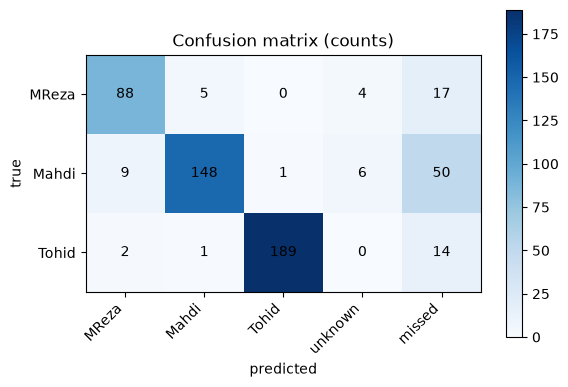

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(confusion, cmap="Blues")
ax.set_xticks(range(len(columns)), columns, rotation=45, ha="right")
ax.set_yticks(range(len(identities)), identities)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Confusion matrix (counts)")
for i in range(len(identities)):
    for j in range(len(columns)):
        ax.text(j, i, confusion[i, j], ha="center", va="center")
fig.colorbar(im)
fig.tight_layout()
fig.savefig("../presentation/eval_plots/confusion_matrix.png", dpi=150)
plt.show()

## Verification analysis: genuine vs. impostor similarity

For every detected golden-set face, compare it against the enrollment gallery: the genuine score
is its best cosine similarity to gallery entries of its own identity, the impostor score is its
best similarity to gallery entries of any other identity. This is threshold-independent and shows
how well-separated identities are, and lets us evaluate `DEFAULT_THRESHOLD` directly.

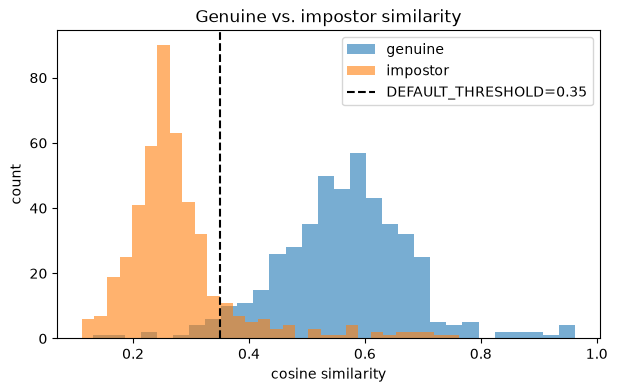

In [7]:
genuine_scores, impostor_scores = [], []
for r in matched:
    similarities = gallery.embeddings @ r["embedding"]
    same_identity = gallery.labels == r["label"]
    genuine_scores.append(similarities[same_identity].max())
    impostor_scores.append(similarities[~same_identity].max())

genuine_scores = np.array(genuine_scores)
impostor_scores = np.array(impostor_scores)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(genuine_scores, bins=30, alpha=0.6, label="genuine")
ax.hist(impostor_scores, bins=30, alpha=0.6, label="impostor")
ax.axvline(DEFAULT_THRESHOLD, color="black", linestyle="--", label=f"DEFAULT_THRESHOLD={DEFAULT_THRESHOLD}")
ax.set_xlabel("cosine similarity")
ax.set_ylabel("count")
ax.set_title("Genuine vs. impostor similarity")
ax.legend()
fig.savefig("../presentation/eval_plots/genuine_vs_impostor.png", dpi=150)
plt.show()

AUC: 0.9562
EER: 0.0762 at threshold 0.404 (current DEFAULT_THRESHOLD=0.35)


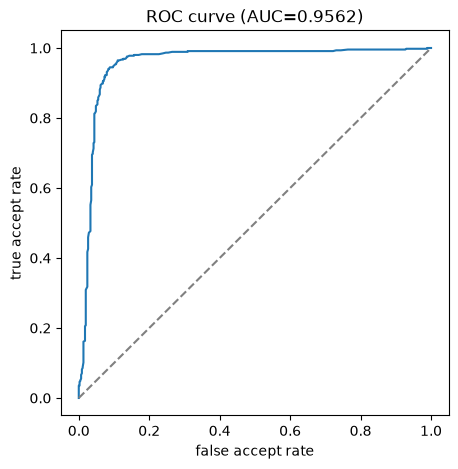

In [8]:
thresholds = np.linspace(0.0, 1.0, 501)
tar = np.array([(genuine_scores >= t).mean() for t in thresholds])  # true accept rate
far = np.array([(impostor_scores >= t).mean() for t in thresholds])  # false accept rate
frr = 1 - tar  # fal se reject rate

auc = -np.trapezoid(tar, far)  # far is decreasing in threshold order, flip sign
eer_idx = np.argmin(np.abs(far - frr))
eer = (far[eer_idx] + frr[eer_idx]) / 2

print(f"AUC: {auc:.4f}")
print(f"EER: {eer:.4f} at threshold {thresholds[eer_idx]:.3f} (current DEFAULT_THRESHOLD={DEFAULT_THRESHOLD})")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(far, tar)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("false accept rate")
ax.set_ylabel("true accept rate")
ax.set_title(f"ROC curve (AUC={auc:.4f})")
fig.savefig("../presentation/eval_plots/roc_curve.png", dpi=150)
plt.show()

## Identification accuracy vs. threshold

Re-run `Gallery.identify` at each candidate threshold (reusing the already-computed embeddings,
no re-detection needed) to see how `DEFAULT_THRESHOLD` compares to the optimum on this golden set.

accuracy at DEFAULT_THRESHOLD=0.35: 0.938
best accuracy 0.960 at threshold 0.000


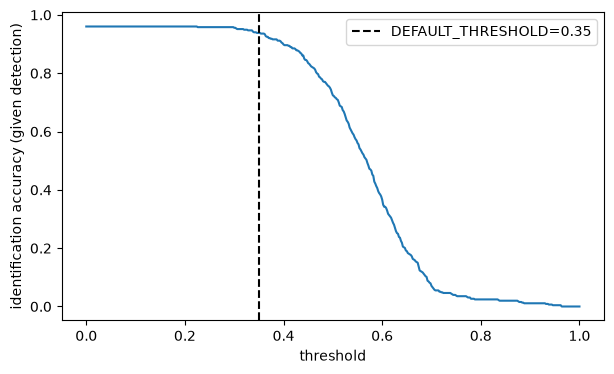

In [9]:
def accuracy_at_threshold(threshold: float) -> float:
    correct = sum(gallery.identify(r["embedding"], threshold=threshold).label == r["label"] for r in matched)
    return correct / len(matched)


accuracies = np.array([accuracy_at_threshold(t) for t in thresholds])
best_idx = np.argmax(accuracies)

print(f"accuracy at DEFAULT_THRESHOLD={DEFAULT_THRESHOLD}: {accuracy_at_threshold(DEFAULT_THRESHOLD):.3f}")
print(f"best accuracy {accuracies[best_idx]:.3f} at threshold {thresholds[best_idx]:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, accuracies)
ax.axvline(DEFAULT_THRESHOLD, color="black", linestyle="--", label=f"DEFAULT_THRESHOLD={DEFAULT_THRESHOLD}")
ax.set_xlabel("threshold")
ax.set_ylabel("identification accuracy (given detection)")
ax.legend()
fig.savefig("../presentation/eval_plots/accuracy_vs_threshold.png", dpi=150)
plt.show()

**Caveat**: every labeled face in the golden set belongs to one of the 3 enrolled identities —
there are no true strangers. So this sweep only trades off `unknown` rejections among *known*
people and pushes the optimum toward threshold 0. It cannot show the cost of a low threshold on
unenrolled faces; the ROC/EER analysis above (impostor = a different enrolled identity) is the
threshold-independent view. A golden set with unlabeled/stranger faces would be needed to properly
tune `DEFAULT_THRESHOLD` for open-set rejection.